In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [29]:
df = pd.read_excel("C:/Users/brent/Downloads/2025_diciembre.xlsx", header=None)
df.head(20)

,0,1,2,3,4,5,6,7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DIRECCION NACIONAL
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE INVESTIGACIONES
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y ANALISIS FISCAL
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-02 00:00:00
4,RECAUDACION TRIBUTARIA. DICIEMBRE DE 2025. (1),NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,en millones de pesos,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
df = pd.read_excel("C:/Users/brent/Downloads/2025_diciembre.xlsx", skiprows=12)
df.head()

,Concepto,Dic. '25,Dic. '24,Dic. '25 /,Nov.'25,Dic. '25 /.1,Ene-Dic '25,Ene.-Dic. '25 /
0,NaN,NaN,NaN,Dic. '24,NaN,Nov.'25,NaN,Ene.-Dic. '24
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ganancias,3.680713e+06,2.559543e+06,43.80353,3.355886e+06,9.679308,3.706317e+07,42.175691
4,Ganancias DGI,3.475808e+06,2.318569e+06,49.911753,3.157151e+06,10.093183,3.437638e+07,45.349938


In [33]:
#Primero seleccionamos explícitamente las columnas:
df = df[["Concepto", "Dic. '25"]]

In [35]:
#Eliminar filas con NaN en Concepto
df = df.dropna(subset=["Concepto"])

In [37]:
#PASO 3 — (Opcional pero recomendado) Resetear índice
df = df.reset_index(drop=True)
df.head()

,Concepto,Dic. '25
0,Ganancias,3.680713e+06
1,Ganancias DGI,3.475808e+06
2,Ganancias DGA,2.049055e+05
3,IVA,5.436360e+06
4,IVA DGI,3.781674e+06


In [39]:
#PASO 4 — (Clave para el proyecto) Renombrar columnas
df = df.rename(columns={
    "Concepto": "impuesto",
    "Dic. '25": "recaudacion_dic_2025"
})
df.head()

,impuesto,recaudacion_dic_2025
0,Ganancias,3.680713e+06
1,Ganancias DGI,3.475808e+06
2,Ganancias DGA,2.049055e+05
3,IVA,5.436360e+06
4,IVA DGI,3.781674e+06


In [67]:
#Automatizar

In [53]:
def procesar_recaudacion_mensual(path_archivo, anio, nombre_mes):
    df = pd.read_excel(path_archivo, skiprows=12)
    
    # Nos quedamos solo con las columnas relevantes
    df = df[["Concepto", df.columns[1]]]
    
    # Eliminamos filas basura
    df = df.dropna(subset=["Concepto"]).reset_index(drop=True)
    
    # Renombramos columnas
    df.columns = ["impuesto", "recaudacion"]
    
    # Agregamos metadatos
    df["anio"] = anio
    df["mes"] = nombre_mes
    
    return df

In [55]:
ruta_carpeta = "C:/Users/brent/Downloads/2025"

dataframes = []

for archivo in os.listdir(ruta_carpeta):
    if archivo.endswith(".xlsx"):
        nombre_mes = archivo.split("_")[1].replace(".xlsx", "")
        path = os.path.join(ruta_carpeta, archivo)
        
        df_mes = procesar_recaudacion_mensual(
            path_archivo=path,
            anio=2025,
            nombre_mes=nombre_mes
        )
        
        dataframes.append(df_mes)


In [87]:
#PASO 1 — Concatenar primero
df_2025 = pd.concat(dataframes, ignore_index=True)
df_2025.head()

,impuesto,recaudacion,anio,mes
0,Ganancias,2.450379e+06,2025,abril
1,Ganancias DGI,2.250668e+06,2025,abril
2,Ganancias DGA,1.997111e+05,2025,abril
3,IVA,4.714093e+06,2025,abril
4,IVA DGI,3.307419e+06,2025,abril


In [89]:
# Podemos llevarlo a anula
df_anual = (
    df_2025
    .groupby(["anio", "impuesto"], as_index=False)
    .agg({"recaudacion": "sum"})
)

In [91]:
#PASO 2 — Asegurar que recaudacion sea numérica
df_2025["recaudacion"] = pd.to_numeric(
    df_2025["recaudacion"],
    errors="coerce"
)

In [93]:
#PASO 3 — rellenar las filas sin recaudacion con 0
df_2025["recaudacion"] = df_2025["recaudacion"].fillna(0)

In [95]:
#PASO 4 — Convertir a entero (pesos)
df_2025["recaudacion"] = df_2025["recaudacion"].astype(int)

In [97]:
#PASO 5 — Formato visual (opcional)
pd.options.display.float_format = '{:,.0f}'.format

In [99]:
#Resultado esperado
df_2025.head()

,impuesto,recaudacion,anio,mes
0,Ganancias,2450378,2025,abril
1,Ganancias DGI,2250667,2025,abril
2,Ganancias DGA,199711,2025,abril
3,IVA,4714092,2025,abril
4,IVA DGI,3307418,2025,abril


In [101]:
 #Recaudación anual por impuesto (2025)
df_recaudacion_2025 = (
    df_2025
    .groupby(["anio","mes", "impuesto"], as_index=False)
    .agg({"recaudacion": "sum"})
)

df_recaudacion_2025.head()

,anio,mes,impuesto,recaudacion
0,2025,abril,el impuesto sobre Pasajes Aéreos y ...,0
1,2025,abril,"30% (F. de Int. Socio Urbana, Obras d...",0
2,2025,abril,"30% de Monotributo impositivo, 10,4% ...",0
3,2025,abril,"6,27% del 11% IVA neto de Reintegros;...",0
4,2025,abril,Devoluciones (-),60000


In [103]:
 #Paso 1.1 — Normalizar nombres de impuestos
def normalizar_impuesto(nombre):
    nombre = nombre.upper()
    if "IVA" in nombre:
        return "IVA"
    elif "GANANCIAS" in nombre:
        return "GANANCIAS"
    elif "TOTAL" in nombre:
        return "TOTAL"
    else:
        return None

In [105]:
df_2025["impuesto_std"] = df_2025["impuesto"].apply(normalizar_impuesto)

In [107]:
 #Paso 1.2 — Filtrar solo los que nos interesan
df_2025_filtrado = df_2025[
    df_2025["impuesto_std"].isin(["IVA", "GANANCIAS", "TOTAL"])
]

In [109]:
 #sumamos todos los meses por impuesto.
df_recaudacion_anual_2025 = (
    df_2025_filtrado
    .groupby(["anio", "impuesto_std"], as_index=False)
    .agg({"recaudacion": "sum"})
)

In [111]:
#Renombramos columnas para que queden dataset-ready:
df_recaudacion_anual_2025 = df_recaudacion_anual_2025.rename(columns={
    "impuesto_std": "impuesto",
    "recaudacion": "recaudacion_pesos"
})

In [113]:
df_recaudacion_anual_2025.head()

,anio,impuesto,recaudacion_pesos
0,2025,GANANCIAS,67570426
1,2025,IVA,111540718
2,2025,TOTAL,421474577


In [121]:
#Exportar dataset final tributario - CSV (recomendado para dataset)
df_recaudacion_anual_2025.to_csv(
    "C:/Users/brent/Downloads/recaudacion_tributaria_anual_2025.csv",
    index=False
)

In [5]:
# Armado de Pipelines
#Función: procesar un AÑO completo (reutilizable)
def procesar_recaudacion_anual(ruta_anio, anio):
    dfs_mensuales = []

    for archivo in os.listdir(ruta_anio):
        if not archivo.endswith(".xlsx"):
            continue

        nombre_mes = archivo.replace(".xlsx", "").split("_")[-1]
        path = os.path.join(ruta_anio, archivo)

        try:
            df = pd.read_excel(path, skiprows=12)

            # Normalizar columnas
            df.columns = (
                df.columns
                .astype(str)
                .str.strip()
                .str.lower()
            )

            # ---- detectar columna de impuesto ----
            posibles_conceptos = [c for c in df.columns if "concepto" in c or "impuesto" in c or "detalle" in c]

            if len(posibles_conceptos) > 0:
                col_impuesto = posibles_conceptos[0]
            else:
                # fallback: primera columna
                col_impuesto = df.columns[0]

            # ---- detectar columna de recaudación ----
            col_recaudacion = df.columns[1]

            df = df[[col_impuesto, col_recaudacion]]
            df.columns = ["impuesto", "recaudacion"]

            # Limpieza
            df = df.dropna(subset=["impuesto"])
            df["recaudacion"] = df["recaudacion"].fillna(0)

            # Metadatos
            df["anio"] = anio
            df["mes"] = nombre_mes

            dfs_mensuales.append(df)

        except Exception as e:
            print(f"⚠️ Error en {anio} - {archivo}: {e}")

    if len(dfs_mensuales) == 0:
        return pd.DataFrame()

    return pd.concat(dfs_mensuales, ignore_index=True)


In [7]:
ruta_base = "C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Recaudacion/Archivos/recaudacion"
dfs_anuales = []

for anio in range(2020, 2026):
    ruta_anio = os.path.join(ruta_base, str(anio))

    df_anio = procesar_recaudacion_anual(
        ruta_anio=ruta_anio,
        anio=anio
    )

    # 👇 Control de DataFrames vacíos
    if not df_anio.empty:
        dfs_anuales.append(df_anio)
    else:
        print(f"⚠️ Año {anio} sin datos válidos")

# -------------------------------
# Dataset final integrado
# -------------------------------
df_total = pd.concat(dfs_anuales, ignore_index=True)

⚠️ Año 2022 sin datos válidos


In [8]:
df_recaudacion_2020_2025 = pd.concat(
    dfs_anuales,
    ignore_index=True
)

In [11]:
df_recaudacion_2020_2025.info()
df_recaudacion_2020_2025.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1815 entries, 0 to 1814
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   impuesto     1815 non-null   object 
 1   recaudacion  1815 non-null   float64
 2   anio         1815 non-null   int64  
 3   mes          1815 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 56.8+ KB


,impuesto,recaudacion,anio,mes
0,Ganancias,141115.245707,2020,agosto
1,Ganancias DGI,133109.706664,2020,agosto
2,Ganancias DGA,8005.539043,2020,agosto
3,IVA,157976.708912,2020,agosto
4,IVA DGI,107902.977341,2020,agosto


In [13]:
#Paso de estandarización
df = df_recaudacion_2020_2025.copy()

df["impuesto_std"] = (
    df["impuesto"]
    .astype(str)     # seguridad extra
    .str.upper()
    .str.strip()
)

df.loc[df["impuesto_std"].str.contains("IVA", na=False), "impuesto_std"] = "IVA"
df.loc[df["impuesto_std"].str.contains("GANAN", na=False), "impuesto_std"] = "GANANCIAS"
df.loc[df["impuesto_std"].str.contains("TOTAL", na=False), "impuesto_std"] = "TOTAL"

In [15]:
#Filtrar IVA + Ganancias + Total
df_filtrado = df[
    df["impuesto_std"].isin(["IVA", "GANANCIAS", "TOTAL"])
].copy()

In [17]:
#Control rapido
df_filtrado["impuesto_std"].value_counts()

impuesto_std
TOTAL        221
IVA          195
GANANCIAS    117
Name: count, dtype: int64

In [19]:
#Consolidar recaudación por año e impuesto
df_consolidado = (
    df_filtrado
    .groupby(["anio", "impuesto_std"], as_index=False)
    .agg(
        recaudacion_total=("recaudacion", "sum")
    )
    .sort_values(["anio", "impuesto_std"])
)

In [21]:
df_consolidado.head()

,anio,impuesto_std,recaudacion_total
0,2020,GANANCIAS,1.302738e+06
1,2020,IVA,1.604043e+06
2,2020,TOTAL,7.607538e+06
3,2021,GANANCIAS,5.808507e+05
4,2021,IVA,9.712435e+05


In [25]:
#Exportar (cuando confirmes que está bien)
df_consolidado.to_csv(
    "C:/Users/brent/OneDrive/Escritorio/ProyectoImpuestos/Recaudacion/Archivos_exportados/recaudacion_iva_ganancias_total_2020_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

1️⃣ Evolución de la recaudación por impuesto (líneas)

Sirve para ver cómo cambia cada impuesto a lo largo del tiempo.

Muy útil para analizar shocks económicos o cambios tributarios.Mostrar solo los principales impuestos (Top 5)

Esto es lo más usado en análisis económico.

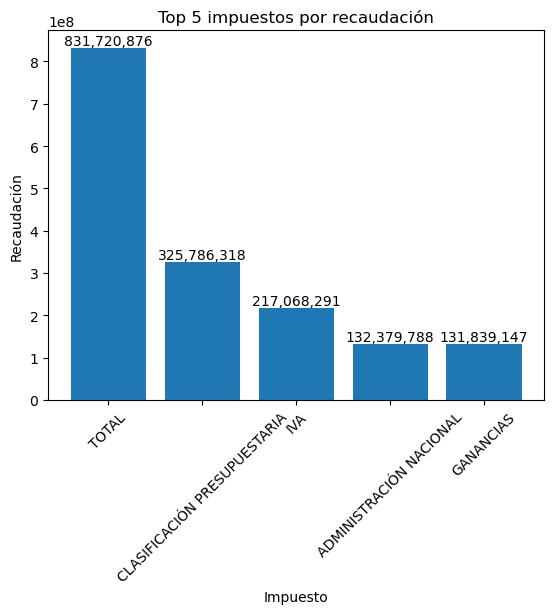

In [48]:
top_impuestos = (
    df.groupby("impuesto_std")["recaudacion"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure()

plt.bar(top_impuestos.index, top_impuestos.values)

plt.title("Top 5 impuestos por recaudación")
plt.xlabel("Impuesto")
plt.ylabel("Recaudación")

plt.xticks(rotation=45)

for i, v in enumerate(top_impuestos.values):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom")

plt.show()

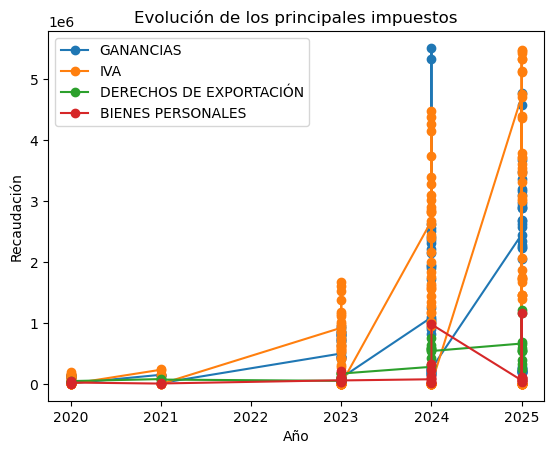

In [42]:
impuestos_clave = [
    "IVA",
    "GANANCIAS",
    "DERECHOS DE EXPORTACIÓN",
    "IMPUESTO PAIS",
    "BIENES PERSONALES"
]

df_clave = df[df["impuesto_std"].isin(impuestos_clave)]

plt.figure()

for impuesto in df_clave["impuesto_std"].unique():
    datos = df_clave[df_clave["impuesto_std"] == impuesto]
    plt.plot(datos["anio"], datos["recaudacion"], marker="o", label=impuesto)

plt.title("Evolución de los principales impuestos")
plt.xlabel("Año")
plt.ylabel("Recaudación")

plt.legend()

plt.show()

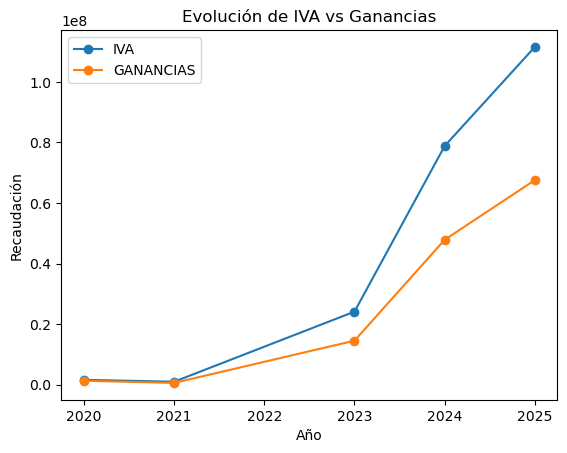

In [44]:
plt.figure()

impuestos = ["IVA", "GANANCIAS"]

for imp in impuestos:
    datos = df[df["impuesto_std"] == imp]
    datos_anual = datos.groupby("anio")["recaudacion"].sum()

    plt.plot(datos_anual.index, datos_anual.values, marker="o", label=imp)

plt.title("Evolución de IVA vs Ganancias")
plt.xlabel("Año")
plt.ylabel("Recaudación")

plt.legend()

plt.show()